# Boosting and Bagging in Machine Learning

This notebook covers **Ensemble Learning** techniques — specifically **Bagging** and **Boosting** — which combine multiple weak/base learners to build a stronger predictive model.

**Contents:**
1. What is Ensemble Learning?
2. Bagging (Bootstrap Aggregating)
   - How it works
   - Random Forest
   - Code demo
3. Boosting
   - How it works
   - AdaBoost
   - Gradient Boosting
   - Code demo
4. Bagging vs Boosting — Key Differences
5. Visual Comparison
6. Summary

## 1. What is Ensemble Learning?

**Ensemble learning** combines predictions from multiple models (called *base learners* or *weak learners*) to produce a single, more accurate and robust prediction than any individual model.

Two of the most popular ensemble strategies are:

| Technique | Idea | Goal |
|---|---|---|
| **Bagging** | Train models independently & in parallel on random subsets of data, then average/vote | Reduce **variance** |
| **Boosting** | Train models sequentially, each correcting errors of the previous one | Reduce **bias** |

## 2. Bagging (Bootstrap Aggregating)

**How it works:**
1. Create multiple random subsets of the training data using **sampling with replacement** (bootstrap samples).
2. Train a separate base model (often a decision tree) on each subset **independently and in parallel**.
3. Combine predictions:
   - **Classification** → majority vote
   - **Regression** → average

Because each model is trained on a slightly different dataset, bagging reduces **overfitting** and **variance**, especially for high-variance models like decision trees.

**Most famous example: Random Forest** — bagging applied to decision trees, with an extra trick of choosing a random subset of *features* at each split (extra randomness → less correlated trees).

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Create a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                            n_redundant=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 700
Testing samples: 300


In [2]:
# --- Single Decision Tree (baseline) ---
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
pred_single = single_tree.predict(X_test)
acc_single = accuracy_score(y_test, pred_single)
print(f"Single Decision Tree Accuracy: {acc_single:.4f}")

Single Decision Tree Accuracy: 0.8167


In [3]:
# --- Bagging Classifier ---
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42
)
bagging_model.fit(X_train, y_train)
pred_bagging = bagging_model.predict(X_test)
acc_bagging = accuracy_score(y_test, pred_bagging)
print(f"Bagging Classifier Accuracy: {acc_bagging:.4f}")

Bagging Classifier Accuracy: 0.9200


In [4]:
# --- Random Forest (Bagging + feature randomness) ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")

Random Forest Accuracy: 0.9167


## 3. Boosting

**How it works:**
1. Train a base model (often a *shallow* decision tree, called a "stump") on the full dataset.
2. Identify the samples it got wrong.
3. Train the next model with **more weight/focus on the misclassified samples**.
4. Repeat sequentially, combining all models into a weighted final prediction.

Boosting builds models **sequentially** (not in parallel like bagging), where each new model tries to fix the mistakes of the previous ones. This reduces **bias** and can turn a collection of weak learners into a strong learner.

**Popular boosting algorithms:**
- **AdaBoost** (Adaptive Boosting) — reweights misclassified samples after each round.
- **Gradient Boosting** — fits new models to the *residual errors* (gradients) of the previous model.
- **XGBoost / LightGBM / CatBoost** — optimized, regularized implementations of gradient boosting (industry standard).

In [5]:
# --- AdaBoost ---
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner (stump)
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada_model.fit(X_train, y_train)
pred_ada = ada_model.predict(X_test)
acc_ada = accuracy_score(y_test, pred_ada)
print(f"AdaBoost Accuracy: {acc_ada:.4f}")

AdaBoost Accuracy: 0.8267


In [6]:
# --- Gradient Boosting ---
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
pred_gb = gb_model.predict(X_test)
acc_gb = accuracy_score(y_test, pred_gb)
print(f"Gradient Boosting Accuracy: {acc_gb:.4f}")

Gradient Boosting Accuracy: 0.9067


## 4. Bagging vs Boosting — Key Differences

| Aspect | Bagging | Boosting |
|---|---|---|
| **Training** | Parallel, independent models | Sequential, each model depends on previous |
| **Data sampling** | Random subsets with replacement (bootstrap) | Full dataset, but sample **weights** change each round |
| **Goal** | Reduce **variance** | Reduce **bias** (and variance) |
| **Base learners** | Usually deep/complex trees | Usually shallow trees (weak learners / stumps) |
| **Overfitting risk** | Lower | Higher (more sensitive to noisy data/outliers) |
| **Speed** | Faster (parallelizable) | Slower (sequential dependency) |
| **Examples** | Random Forest, Bagging Classifier | AdaBoost, Gradient Boosting, XGBoost, LightGBM |

## 5. Visual Comparison of All Models

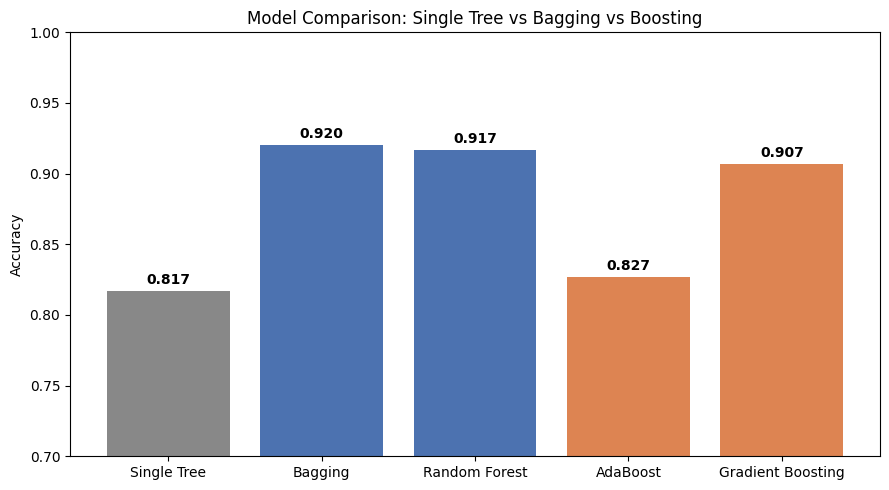

In [7]:
# Compare accuracy of all models
models = ['Single Tree', 'Bagging', 'Random Forest', 'AdaBoost', 'Gradient Boosting']
accuracies = [acc_single, acc_bagging, acc_rf, acc_ada, acc_gb]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accuracies, color=['#888888', '#4C72B0', '#4C72B0', '#DD8452', '#DD8452'])
plt.ylabel('Accuracy')
plt.title('Model Comparison: Single Tree vs Bagging vs Boosting')
plt.ylim(0.7, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

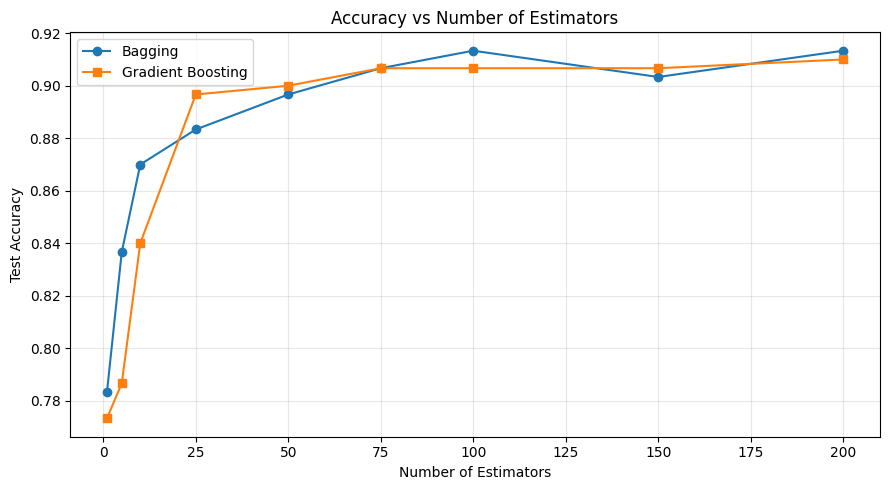

In [8]:
# Effect of number of estimators on Boosting vs Bagging performance
n_estimators_range = [1, 5, 10, 25, 50, 75, 100, 150, 200]

bagging_scores = []
boosting_scores = []

for n in n_estimators_range:
    bg = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=n, random_state=42)
    bg.fit(X_train, y_train)
    bagging_scores.append(accuracy_score(y_test, bg.predict(X_test)))

    gb = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, random_state=42)
    gb.fit(X_train, y_train)
    boosting_scores.append(accuracy_score(y_test, gb.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_estimators_range, bagging_scores, marker='o', label='Bagging')
plt.plot(n_estimators_range, boosting_scores, marker='s', label='Gradient Boosting')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs Number of Estimators')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary

- **Bagging** trains multiple models independently on bootstrapped samples and averages/votes on results. It mainly **reduces variance** and works great with high-variance models like deep decision trees (e.g., **Random Forest**).
- **Boosting** trains models sequentially, each one focusing on the mistakes of the previous model. It mainly **reduces bias** and can turn weak learners into a strong learner (e.g., **AdaBoost**, **Gradient Boosting**, **XGBoost**).
- Both are ensemble methods, but they differ in **how** models are trained (parallel vs sequential) and **what** problem they primarily solve (variance vs bias).
- In practice:
  - Use **Bagging/Random Forest** when your base model overfits (high variance) and you want stability.
  - Use **Boosting** when your base model underfits (high bias) and you need higher accuracy, being mindful of overfitting and outliers.

### Further Exploration
- Try `XGBoost`, `LightGBM`, or `CatBoost` for production-grade boosting.
- Tune hyperparameters like `n_estimators`, `learning_rate`, `max_depth` using `GridSearchCV`.
- Explore **Stacking** — another ensemble technique that combines different types of models using a meta-learner.